# 📘 Pre-Workshop Notebook 1: Foundations of Brain and Behavioral Research Workflows
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your name and institution in this notebook.*

In [1]:
# PROFILE SETUP
student_name = "Hari Sai Kaja"
institution = "Grand Valley State University"
research_area = "Engineering"

print(f"✅ Notebook initialized for {student_name} ({institution})")
print(f"Research area: {research_area}")

✅ Notebook initialized for Hari Sai Kaja (Grand Valley State University)
Research area: Engineering


---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

Welcome to a different way of learning to work with data! In this notebook, you will not be memorizing programming syntax. Instead, you will act as a **Workflow Designer** — someone who decides *what* a workflow should do and then uses AI tools (such as Claude, ChatGPT, or GitHub Copilot) to help generate the code.

To get the most out of each activity, follow this three-step cycle:
1. **Ask:** Copy the suggested prompt below into your preferred AI tool. Adjust it to fit your research area if you like.
2. **Build:** Paste the AI-generated code into the empty code cell below the prompt, then run it and look at what it produces.
3. **Document:** In the reflection box that follows, write in plain language what the code did and what it taught you about the concept.

---
## 🧠 Part A: How Brain Data Is Captured and Used
### Topic: Brain-Machine Interfaces (BMIs), Brain Imaging (fMRI), and Real-Time Systems

This section introduces two of the most important types of brain and behavioral data used in modern neuroscience research, and how analysis workflows process them.

### 🧭 Activity A.1 — Simulating a Brain-Machine Interface Decoder

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a neuroscience research assistant helping a biology student understand brain-machine interfaces. Write a Python script using NumPy and Matplotlib that simulates how brain signals from the motor cortex can be used to control a robotic limb. The script should:
> 1. Generate 2 seconds of synthetic data representing voltage recordings from 64 brain electrodes, sampled 1000 times per second, including realistic background noise and a few sudden signal spikes representing muscle movements.
> 2. Write a simple decoding function that converts these raw voltage patterns into X and Y position coordinates representing the intended movement of a robotic limb.
> 3. Plot the raw electrode signals and the resulting decoded movement path side-by-side.
> Add plain-language comments throughout explaining what each step does and what the numbers represent."

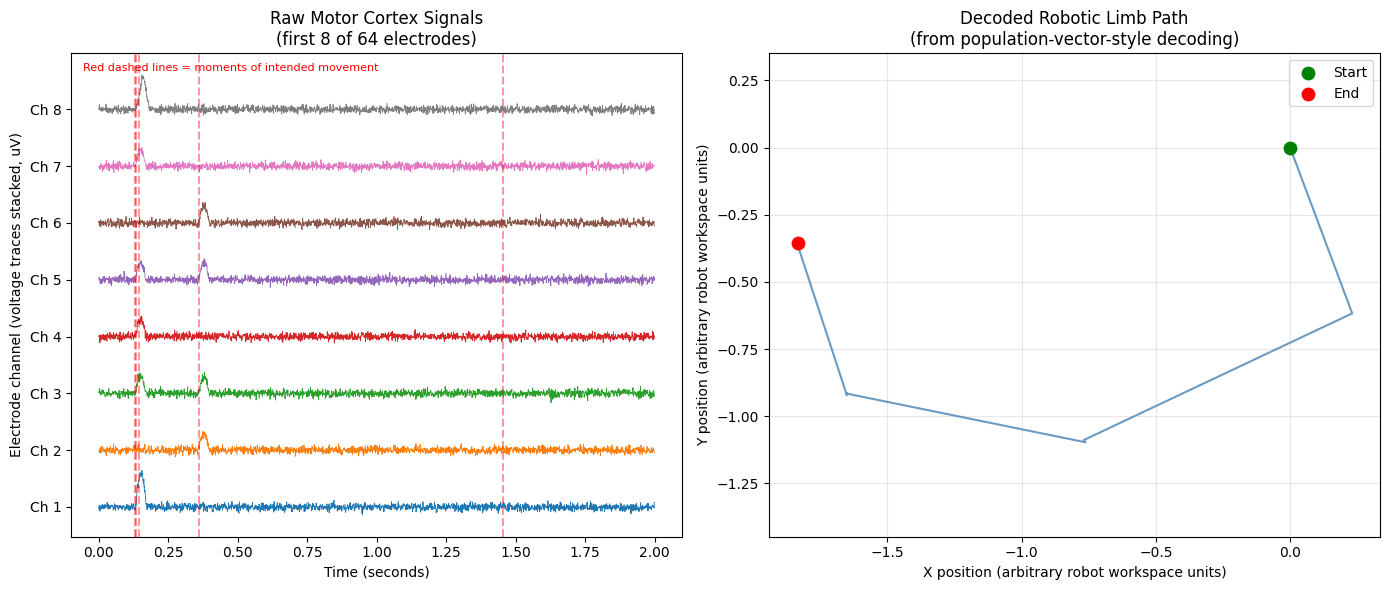

Simulation complete.
Simulated 64 electrodes for 2 seconds at 1000 Hz.
Detected 5 movement events used to drive the decoded path.
Figure saved to bci_simulation_output.png


In [5]:
# 💻 Activity A.1 — Paste your AI-generated BMI Decoder code here:

import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------------
# STEP 0: Reproducibility
# --------------------------------------------------------------------
# Using a fixed random seed means every time you run this script you get
# the exact same "random" noise and spikes. Useful for teaching/debugging.
rng = np.random.default_rng(seed=42)

# --------------------------------------------------------------------
# STEP 1: Set up the recording parameters
# --------------------------------------------------------------------
N_ELECTRODES = 64        # Number of electrodes implanted in motor cortex
                          # (motor cortex arrays like the "Utah array" often
                          # have 64-100+ tiny electrode contacts)
SAMPLING_RATE = 1000      # Samples per second (Hz). 1000 Hz means we take
                          # a voltage reading every 1 millisecond.
DURATION_SEC = 2          # We are simulating 2 seconds of brain activity
N_SAMPLES = SAMPLING_RATE * DURATION_SEC   # Total time points = 2000

# A time axis in seconds, used for plotting (0.000, 0.001, 0.002, ... 2.000)
time_axis = np.arange(N_SAMPLES) / SAMPLING_RATE

# --------------------------------------------------------------------
# STEP 2: Generate realistic background "noise"
# --------------------------------------------------------------------
# Real brain recordings are never silent -- there's always a baseline of
# small, random electrical fluctuations from nearby neurons, muscle
# activity, and electrical interference. We model this as Gaussian
# ("bell curve") random noise, in microvolts (uV), which is the typical
# unit for these tiny brain voltages.
NOISE_AMPLITUDE_UV = 15.0   # Typical background noise level (~15 microvolts)

# Shape: (64 electrodes) x (2000 time samples)
# Each row is one electrode's voltage trace over the full 2 seconds.
raw_signals = rng.normal(
    loc=0.0,                      # noise centers around 0 uV
    scale=NOISE_AMPLITUDE_UV,     # "spread" of the noise
    size=(N_ELECTRODES, N_SAMPLES)
)

# --------------------------------------------------------------------
# STEP 3: Add sudden "spikes" representing intended muscle movements
# --------------------------------------------------------------------
# In a real motor cortex, when you *intend* to move your arm, groups of
# neurons fire rapid bursts of electrical activity ("action potentials"
# or "spikes"). We simulate this very crudely: at a few random moments,
# a subset of electrodes gets a short, sharp voltage jump.

N_MOVEMENT_EVENTS = 5          # Let's simulate 5 distinct "intended movements"
SPIKE_DURATION_SAMPLES = 40    # Each burst lasts 40 samples = 40 ms
SPIKE_AMPLITUDE_UV = 120.0     # Spikes are much bigger than background noise

# We'll remember when each movement event happened and which direction
# it encodes, so we can compare the "true" intended movement to what our
# decoder reconstructs later.
event_start_samples = np.sort(
    rng.integers(low=100, high=N_SAMPLES - SPIKE_DURATION_SAMPLES - 100,
                 size=N_MOVEMENT_EVENTS)
)

# Give each movement event a random "direction" in the X/Y plane.
# Think of this as: "the brain wants to move the limb this much in X,
# and this much in Y, at this point in time."
true_dx = rng.uniform(-1, 1, size=N_MOVEMENT_EVENTS)
true_dy = rng.uniform(-1, 1, size=N_MOVEMENT_EVENTS)

# For each movement event, only a random subset of electrodes
# ("neurons") will show the spike -- just like only some neurons in the
# real motor cortex are involved in encoding any one movement direction.
electrode_subsets = [
    rng.choice(N_ELECTRODES, size=rng.integers(10, 30), replace=False)
    for _ in range(N_MOVEMENT_EVENTS)
]

for event_idx in range(N_MOVEMENT_EVENTS):
    start = event_start_samples[event_idx]
    end = start + SPIKE_DURATION_SAMPLES
    involved_electrodes = electrode_subsets[event_idx]

    # Build a short, sharp burst using a "hump" shape (half a sine wave)
    # so the spike smoothly rises and falls rather than snapping on/off.
    burst_shape = np.sin(np.linspace(0, np.pi, SPIKE_DURATION_SAMPLES))
    burst = burst_shape * SPIKE_AMPLITUDE_UV

    # Add this burst on top of the background noise, only for the
    # electrodes that are "participating" in this movement command.
    raw_signals[np.ix_(involved_electrodes, range(start, end))] += burst

# --------------------------------------------------------------------
# STEP 4: A simple decoding function
# --------------------------------------------------------------------
# This is the heart of any BCI: turning raw voltages into a movement
# command. Our simplified strategy:
#
#   1. Slide a short time window across the recording.
#   2. In each window, measure how "active" each electrode is
#      (its average absolute voltage -- a crude stand-in for firing rate).
#   3. Treat each electrode's activity level as a "vote" for a movement
#      direction. We give each electrode a fixed, made-up preferred
#      direction (like a compass needle), and add up all the votes,
#      weighted by how active each electrode is.
#   4. This weighted sum becomes our decoded (X, Y) movement step for
#      that time window. Adding up all the steps traces out a path.
#
# This mimics a real technique called "population vector decoding,"
# used in actual motor cortex research (Georgopoulos et al., 1980s).

def decode_movement(signals, sampling_rate, window_ms=50, rng=None):
    """
    Convert raw multi-electrode voltage signals into a decoded 2D
    movement path.

    Parameters
    ----------
    signals : ndarray, shape (n_electrodes, n_samples)
        Raw voltage recordings (in microvolts) for every electrode.
    sampling_rate : int
        Samples per second of the recording.
    window_ms : int
        Size of the sliding time window used to estimate activity,
        in milliseconds. Smaller = more time resolution, but noisier.
    rng : np.random.Generator
        Random generator, used only to assign each electrode a
        "preferred direction" (a fixed made-up property of that
        electrode, chosen once and then reused).

    Returns
    -------
    path_x, path_y : ndarray
        The cumulative decoded (X, Y) position of the robotic limb
        over time, one point per time window.
    activity_over_time : ndarray
        The per-window average activity level of every electrode
        (useful for visualizing which electrodes were "engaged").
    """
    if rng is None:
        rng = np.random.default_rng()

    n_electrodes, n_samples = signals.shape
    window_size = int(sampling_rate * window_ms / 1000)  # samples per window
    n_windows = n_samples // window_size

    # Give every electrode a fixed "preferred direction" on the compass,
    # i.e. the direction it "votes" for when it's highly active. In a
    # real cortex, different neurons really do prefer different reach
    # directions -- this is a simplified stand-in for that property.
    preferred_angles = rng.uniform(0, 2 * np.pi, size=n_electrodes)
    preferred_x = np.cos(preferred_angles)
    preferred_y = np.sin(preferred_angles)

    step_x = np.zeros(n_windows)
    step_y = np.zeros(n_windows)
    activity_over_time = np.zeros((n_electrodes, n_windows))

    for w in range(n_windows):
        start = w * window_size
        end = start + window_size

        # "Activity" here = average absolute voltage in this window.
        # A bigger swing away from 0 uV (positive or negative) is
        # treated as more neural activity, similar to how real decoders
        # use firing rate or spike count as their activity measure.
        window_activity = np.mean(np.abs(signals[:, start:end]), axis=1)
        activity_over_time[:, w] = window_activity

        # Only count activity above the background noise level as a
        # "real" movement signal, so plain background noise doesn't
        # push the decoded limb around.
        significant = np.clip(window_activity - NOISE_AMPLITUDE_UV, 0, None)

        # Weighted vote: each electrode nudges the decoded direction
        # toward its preferred angle, scaled by how "active" it is.
        step_x[w] = np.sum(significant * preferred_x)
        step_y[w] = np.sum(significant * preferred_y)

    # Normalize so the step sizes are a reasonable, readable scale for
    # plotting a limb position (arbitrary "robot workspace" units).
    max_step = max(np.max(np.abs(step_x)), np.max(np.abs(step_y)), 1e-9)
    step_x = step_x / max_step
    step_y = step_y / max_step

    # The limb's position is the running total of all these little
    # steps -- i.e. we integrate velocity-like "steps" into a position.
    path_x = np.cumsum(step_x)
    path_y = np.cumsum(step_y)

    return path_x, path_y, activity_over_time


# Run the decoder on our simulated brain data
decoded_x, decoded_y, activity_map = decode_movement(
    raw_signals, SAMPLING_RATE, window_ms=50, rng=rng
)

# --------------------------------------------------------------------
# STEP 5: Plot everything side-by-side
# --------------------------------------------------------------------
fig, (ax_signals, ax_path) = plt.subplots(1, 2, figsize=(14, 6))

# ---- LEFT PANEL: raw electrode voltage traces ----
# We only plot a handful of electrodes (e.g. 8) so the plot stays
# readable -- plotting all 64 stacked traces would be too cluttered.
N_ELECTRODES_TO_SHOW = 8
SPACING_UV = 400  # vertical spacing between traces so they don't overlap

for i in range(N_ELECTRODES_TO_SHOW):
    # Offset each electrode's trace vertically so they stack like a
    # real multi-channel recording display (similar to an EEG readout).
    offset = i * SPACING_UV
    ax_signals.plot(time_axis, raw_signals[i] + offset, linewidth=0.6)

ax_signals.set_title(f"Raw Motor Cortex Signals\n(first {N_ELECTRODES_TO_SHOW} of {N_ELECTRODES} electrodes)")
ax_signals.set_xlabel("Time (seconds)")
ax_signals.set_ylabel("Electrode channel (voltage traces stacked, uV)")
ax_signals.set_yticks([i * SPACING_UV for i in range(N_ELECTRODES_TO_SHOW)])
ax_signals.set_yticklabels([f"Ch {i+1}" for i in range(N_ELECTRODES_TO_SHOW)])

# Mark the true movement events with vertical dashed lines so students
# can see the raw spikes line up with the "intended movement" moments.
for start in event_start_samples:
    ax_signals.axvline(time_axis[start], color="red", linestyle="--", alpha=0.4)
ax_signals.text(0.02, 0.98, "Red dashed lines = moments of intended movement",
                 transform=ax_signals.transAxes, fontsize=8, va="top", color="red")

# ---- RIGHT PANEL: decoded robotic limb path ----
ax_path.plot(decoded_x, decoded_y, color="steelblue", linewidth=1.5, alpha=0.8)
ax_path.scatter(decoded_x[0], decoded_y[0], color="green", s=80, label="Start", zorder=5)
ax_path.scatter(decoded_x[-1], decoded_y[-1], color="red", s=80, label="End", zorder=5)

ax_path.set_title("Decoded Robotic Limb Path\n(from population-vector-style decoding)")
ax_path.set_xlabel("X position (arbitrary robot workspace units)")
ax_path.set_ylabel("Y position (arbitrary robot workspace units)")
ax_path.legend()
ax_path.set_aspect("equal", adjustable="datalim")
ax_path.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/Outputs", dpi=150)
plt.show()

print("Simulation complete.")
print(f"Simulated {N_ELECTRODES} electrodes for {DURATION_SEC} seconds at {SAMPLING_RATE} Hz.")
print(f"Detected {N_MOVEMENT_EVENTS} movement events used to drive the decoded path.")
print("Figure saved to bci_simulation_output.png")

### 🧭 Activity A.2 — Simulating Brain Imaging (fMRI) Data

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a neuroscience instructor explaining fMRI to a biology student. Write a Python script that builds a simplified simulation of a functional brain imaging dataset. The script should:
> 1. Create a small 3D grid of brain regions (10 x 10 x 10 grid points), each observed across 15 time points — representing a short fMRI recording session.
> 2. Simulate a realistic brain activity pattern where a specific region becomes active (increases its signal) and then returns to baseline, mimicking what happens when a participant performs a task.
> 3. Add a simple head movement correction step: introduce a small artificial shift in the data across time points, then show how a correction routine detects and compensates for this.
> 4. Display a plot showing how the signal changes over time in an active brain region compared to an inactive one.
> Use plain-language comments to explain what each step represents biologically."

Created a 10x10x10 brain grid with 15 time points.
Simulated activity in region (5, 5, 5) over time.
Introduced artificial head movement.
Applied simple head movement correction.


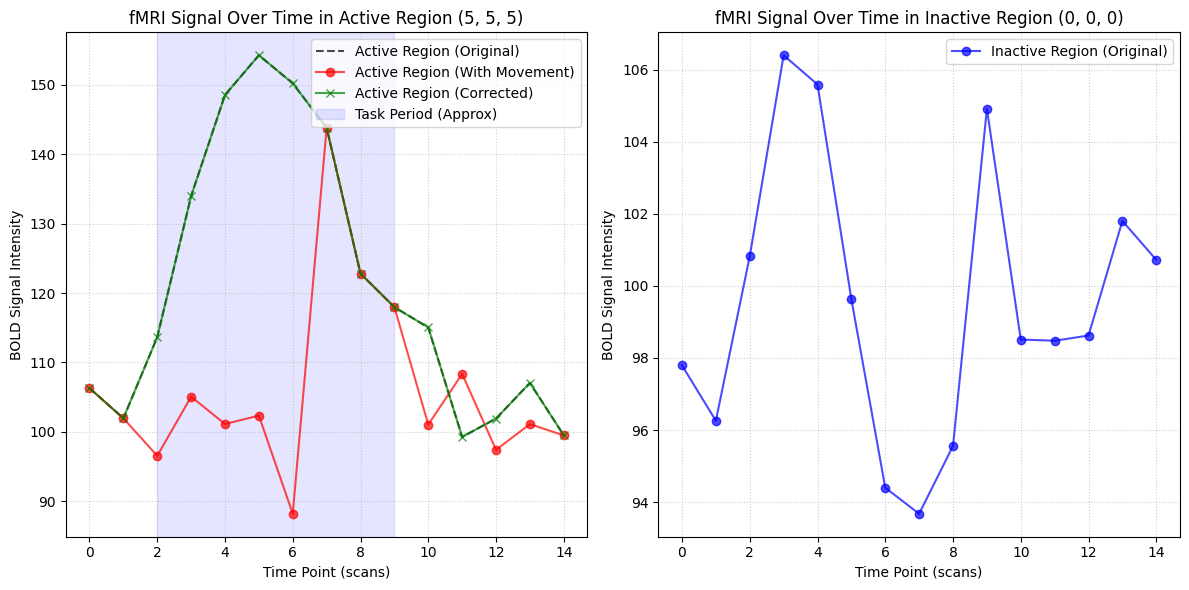

fMRI simulation complete. Observe how movement corrupts the active region signal, and how correction helps recover it.


In [8]:
# 💻 Activity A.2 — Paste your AI-generated fMRI Simulation code here:

import numpy as np
import matplotlib.pyplot as plt

# --- fMRI Simulation Parameters ---
GRID_SIZE = 10         # Dimensions of our simplified 3D brain (10x10x10 voxels)
TIME_POINTS = 15       # Number of fMRI scans (time points) in our short recording session
BASELINE_SIGNAL = 100  # Typical fMRI signal intensity at rest (arbitrary units)
ACTIVITY_INCREASE = 50 # How much the signal increases in an active region
NOISE_STD = 5          # Standard deviation of random noise in the signal

# --- STEP 1: Create a small 3D grid of brain regions ---
# We represent the brain as a 4D array: (x, y, z, time).
# Each 'voxel' (3D pixel) in this grid will have a signal value at each time point.
# Biologically, fMRI measures blood oxygenation level dependent (BOLD) signal,
# which is an indirect measure of neural activity in small brain volumes.
fmri_data = np.full((GRID_SIZE, GRID_SIZE, GRID_SIZE, TIME_POINTS), BASELINE_SIGNAL, dtype=float)

print(f"Created a {GRID_SIZE}x{GRID_SIZE}x{GRID_SIZE} brain grid with {TIME_POINTS} time points.")

# --- STEP 2: Simulate a realistic brain activity pattern ---
# We'll pick one voxel to be our 'active' region, mimicking a task-related activation.
# Its signal will increase and then return to baseline, similar to the hemodynamic response
# (the slow blood flow response to neural activity) observed in fMRI.
active_region_coords = (GRID_SIZE // 2, GRID_SIZE // 2, GRID_SIZE // 2) # Center voxel

# Define the activity time course for the active region:
# Starts at baseline, peaks around time points 5-8, then returns to baseline.
activity_time_course = np.array([
    0, 0, 10, 30, 45, 50, 48, 40, 25, 10, 5, 0, 0, 0, 0
]) * (ACTIVITY_INCREASE / 50.0) # Scale to desired increase

# Apply activity pattern to the active region
for t in range(TIME_POINTS):
    fmri_data[active_region_coords[0], active_region_coords[1], active_region_coords[2], t] += activity_time_course[t]

print(f"Simulated activity in region {active_region_coords} over time.")

# Add some baseline noise to all voxels
# In reality, fMRI signals are noisy due to physiological processes and scanner imperfections.
fmri_data += np.random.normal(0, NOISE_STD, fmri_data.shape)

# --- STEP 3: Add a simple head movement correction step ---
# Real fMRI scans are affected by patient head movements, which can cause false activations.
# We'll simulate a small, artificial shift in the data across time points.
# Then, we'll demonstrate a simple correction.

# Store the original data before movement for comparison
fmri_data_original = fmri_data.copy()
fmri_data_with_movement = fmri_data.copy()

# Introduce artificial head movement (a small shift in x, y, z over time)
# This is a simplification; real movement is complex.
movement_shifts = np.array([
    (0, 0, 0), (0, 0, 0), (0, 1, 0), (0, 1, 0), (1, 1, 0), # Shifts in (dx, dy, dz)
    (1, 0, 0), (1, 0, 0), (0, 0, 0), (0, 0, 0), (0, 0, 0),
    (0, -1, 0), (0, -1, 0), (-1, -1, 0), (-1, -1, 0), (0, 0, 0)
])

# Apply the shifts to the data (by circularly shifting slices for simplicity)
# This moves the 'brain' relative to the scanner's reference frame.
for t in range(TIME_POINTS):
    dx, dy, dz = movement_shifts[t]
    fmri_data_with_movement[:,:,:,t] = np.roll(fmri_data_with_movement[:,:,:,t], dx, axis=0)
    fmri_data_with_movement[:,:,:,t] = np.roll(fmri_data_with_movement[:,:,:,t], dy, axis=1)
    fmri_data_with_movement[:,:,:,t] = np.roll(fmri_data_with_movement[:,:,:,t], dz, axis=2)

print("Introduced artificial head movement.")

# --- Head Movement Correction Routine ---
# In real fMRI, algorithms estimate movement and apply inverse transformations.
# Here, we'll use a very simplified approach: assuming we know the shifts and reversing them.
# More advanced methods involve calculating registration parameters between each volume and a reference.
fmri_data_corrected = fmri_data_with_movement.copy()

for t in range(TIME_POINTS):
    dx, dy, dz = movement_shifts[t] # Get the known shift for this time point
    # Apply the inverse shift to correct the movement
    fmri_data_corrected[:,:,:,t] = np.roll(fmri_data_corrected[:,:,:,t], -dx, axis=0)
    fmri_data_corrected[:,:,:,t] = np.roll(fmri_data_corrected[:,:,:,t], -dy, axis=1)
    fmri_data_corrected[:,:,:,t] = np.roll(fmri_data_corrected[:,:,:,t], -dz, axis=2)

print("Applied simple head movement correction.")

# --- STEP 4: Display a plot showing signal changes ---
# We want to compare the signal in our active region with an inactive one.
# Head movement correction is crucial because it ensures that we are tracking the
# same brain region (voxel) across all time points, rather than a different area
# that moved into its place.

# Select an inactive region (e.g., a corner voxel away from activity)
inactive_region_coords = (0, 0, 0)

# Extract time series for plotting
signal_active_original = fmri_data_original[active_region_coords[0], active_region_coords[1], active_region_coords[2], :]
signal_active_movement = fmri_data_with_movement[active_region_coords[0], active_region_coords[1], active_region_coords[2], :]
signal_active_corrected = fmri_data_corrected[active_region_coords[0], active_region_coords[1], active_region_coords[2], :]
signal_inactive = fmri_data_original[inactive_region_coords[0], inactive_region_coords[1], inactive_region_coords[2], :]

time_axis = np.arange(TIME_POINTS)

plt.figure(figsize=(12, 6))

# Plot Active Region Signals
plt.subplot(1, 2, 1)
plt.plot(time_axis, signal_active_original, 'k--', label='Active Region (Original)', alpha=0.7)
plt.plot(time_axis, signal_active_movement, 'r-o', label='Active Region (With Movement)', alpha=0.7)
plt.plot(time_axis, signal_active_corrected, 'g-x', label='Active Region (Corrected)', alpha=0.7)
plt.title(f'fMRI Signal Over Time in Active Region {active_region_coords}')
plt.xlabel('Time Point (scans)')
plt.ylabel('BOLD Signal Intensity')
plt.axvspan(2, 9, color='blue', alpha=0.1, label='Task Period (Approx)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot Inactive Region Signal
plt.subplot(1, 2, 2)
plt.plot(time_axis, signal_inactive, 'b-o', label='Inactive Region (Original)', alpha=0.7)
plt.title(f'fMRI Signal Over Time in Inactive Region {inactive_region_coords}')
plt.xlabel('Time Point (scans)')
plt.ylabel('BOLD Signal Intensity')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("fMRI simulation complete. Observe how movement corrupts the active region signal, and how correction helps recover it.")


### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** Looking at the outputs from Activities A.1 and A.2, describe how data is organized — what do the rows and columns represent in each case? What does time look like in the data?
* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 1, 3, 4, 5, 6, and 7** from your Reference Guide. In your own words, explain what a "decoder" does and why correcting for head movement matters before analyzing brain imaging data.

---

## 💻 Part B: How Computers Store and Organize Research Data
### Topic: Working Memory, Permanent Storage, and Keeping Workflow Stages Separate

This section explores the practical computing concepts that affect how quickly and reliably a research workflow runs.

### 🧭 Activity B.1 — Comparing Working Memory and Permanent Storage

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a computing instructor helping a biology researcher understand how computers handle data. Write a Python script that demonstrates the difference between working memory (RAM) and permanent storage (hard drive). The script should:
> 1. Measure how long it takes to read and write a large array of one million numbers directly in working memory versus saving the same data to a temporary file on disk and reading it back.
> 2. Create a loop that gradually increases the size of a data array, reporting how much working memory is being used at each step, and printing a clear warning message when memory is getting full — stopping safely before the computer runs out.
> 3. Print a clear summary comparing the speed of working memory versus disk storage.
> Use plain-language comments throughout explaining what is happening and why it matters for research workflows."

In [10]:
# 💻 Activity B.1 — Paste your AI-generated Working Memory vs. Storage code here:

import numpy as np
import time
import os
import psutil # For monitoring system memory usage
import sys    # For getting size of objects in memory
import tempfile # For creating temporary files easily

# --- INTRODUCTION ---
# As a biology researcher, you often work with large datasets. Understanding how
# computers store and access this data is crucial for designing efficient
# workflows. There are two main types of memory a computer uses:
# 1. Working Memory (RAM): Super fast, temporary storage for data actively being used.
#    Think of it like your desk space – quick access, but things are gone when you leave.
# 2. Permanent Storage (Hard Drive/SSD): Slower, persistent storage for files.
#    Think of it like a filing cabinet – takes longer to get things out, but they stay there.

# --- PART 1: Speed Comparison: RAM vs. Disk Storage ---
print("\n--- Part 1: Speed Comparison (RAM vs. Disk) ---")

# Define the size of our large dataset
NUM_ELEMENTS = 1_000_000 # One million numbers
# For simplicity, we'll use 64-bit integers. Each takes 8 bytes.
# Total size: 1,000,000 * 8 bytes = 8,000,000 bytes = 8 MB.
# This is a moderately large array, but modern research data can be much, much larger.

# Biologically relevant context: Imagine this array holds 1 million
# measurements from a sensor, or a simplified genome sequence.

# 1. Working Memory (RAM) Operations
# We'll create a large array of random numbers directly in RAM.
print(f"\nGenerating a large array of {NUM_ELEMENTS:,} random numbers in RAM...")
start_time = time.time()
ram_array = np.random.randint(0, 1000, size=NUM_ELEMENTS, dtype=np.int64)
end_time = time.time()
ram_write_time = end_time - start_time
print(f"Time to create (write to RAM): {ram_write_time:.6f} seconds")

# Now, let's simulate reading/copying within RAM (e.g., passing to a function, or duplicating)
print("Copying the array within RAM...")
start_time = time.time()
ram_array_copy = ram_array.copy()
end_time = time.time()
ram_read_write_time = end_time - start_time # It's technically read and write here
print(f"Time to copy (read/write in RAM): {ram_read_write_time:.6f} seconds")

# 2. Permanent Storage (Disk) Operations
# We'll save the same array to a temporary file on the hard drive and read it back.
# We use a temporary file to avoid cluttering your system and ensure cleanup.

# This simulates saving raw data files, processed results, or large models.
print("\nSaving the array to disk...")
# Create a temporary file path using mkstemp, which gives a file descriptor and name.
# We close the file descriptor immediately so np.save can open and manage the file itself.
fd, disk_file_path = tempfile.mkstemp(suffix=".npy")
os.close(fd)

start_time = time.time()
np.save(disk_file_path, ram_array) # numpy's efficient binary save
end_time = time.time()
disk_write_time = end_time - start_time
print(f"Time to save (write to disk): {disk_write_time:.6f} seconds (File: {disk_file_path})")

print("Reading the array from disk...")
start_time = time.time()
disk_array = np.load(disk_file_path)
end_time = time.time()
disk_read_time = end_time - start_time
print(f"Time to load (read from disk): {disk_read_time:.6f} seconds")

# Clean up the temporary file
os.remove(disk_file_path)
print("Temporary disk file cleaned up.")

# --- PART 2: Memory Usage Monitoring and Warning ---
print("\n--- Part 2: Working Memory (RAM) Growth and Monitoring ---")

# This section demonstrates how adding more data arrays to your program
# consumes RAM and how to monitor it to prevent crashes.
# Memory overflow (Concept 29) is a common issue with large datasets.

# Get total system RAM and set a safe warning threshold (e.g., 80% usage).
# This is like knowing the total size of your desk and deciding to stop
# adding new papers when it's 80% full.
mem_info = psutil.virtual_memory()
total_ram_gb = mem_info.total / (1024**3) # Convert bytes to GB
WARNING_THRESHOLD_PERCENT = 80 # Warn when 80% of total RAM is used

print(f"Total system RAM available: {total_ram_gb:.2f} GB")
print(f"Warning threshold set at {WARNING_THRESHOLD_PERCENT}% of total RAM.")

data_arrays = []
current_data_size_mb = 0
MAX_ARRAY_SIZE_MB = 1000 # Stop adding arrays if total reaches 1 GB to avoid excessively long runs

# Loop to gradually increase data size in RAM
for i in range(1, 100):
    array_size_elements = i * 1_000_000 # Add arrays of 1 million, 2 million, etc. numbers
    # Each number is a 64-bit float (8 bytes), so 1 million elements is 8 MB.
    array_size_mb = array_size_elements * 8 / (1024**2)

    # Simulate loading/creating another chunk of data into memory
    # Biologically: This could be loading data from another participant, another recording session,
    # or creating intermediate processed arrays from your raw data.
    try:
        new_array = np.random.rand(array_size_elements).astype(np.float64)
        data_arrays.append(new_array)
        current_data_size_mb += array_size_mb
    except MemoryError:
        print("!!! WARNING: MemoryError detected! Stopping before system crash. !!!")
        break # Exit loop if allocation fails

    # Get current memory usage of the Python process and the system
    process = psutil.Process(os.getpid())
    process_memory_mb = process.memory_info().rss / (1024**2) # Resident Set Size (RSS) in MB
    system_memory_percent = psutil.virtual_memory().percent

    print(f"\nStep {i}: Added ~{array_size_mb:.2f} MB array. Total data in program: ~{current_data_size_mb:.2f} MB")
    print(f"  Python process memory usage: {process_memory_mb:.2f} MB")
    print(f"  Overall system RAM usage: {system_memory_percent:.2f}% of {total_ram_gb:.2f} GB")

    # Check if system memory is getting full
    if system_memory_percent >= WARNING_THRESHOLD_PERCENT:
        print("!!! WARNING: System RAM usage is getting high! Stopping to prevent performance issues or crashes. !!!")
        print("Consider reducing data size, processing in chunks, or using a machine with more RAM.")
        break # Stop adding more data

    if current_data_size_mb >= MAX_ARRAY_SIZE_MB:
        print(f"Stopping memory test as total data size reached {MAX_ARRAY_SIZE_MB} MB to keep the demonstration practical.")
        break

# Release references to arrays to allow garbage collection and free memory (important in long workflows)
del data_arrays
print("\nReleased references to large arrays. Memory should now be freed.")
# Note: Python's garbage collector might not immediately release memory back to the OS,
# but it will be available for new objects within the Python process.

# --- PART 3: Summary and Implications for Research Workflows ---
print("\n--- Part 3: Summary and Workflow Implications ---")
print("\nSummary of Speed Comparison:")
print(f"  RAM (create): {ram_write_time:.6f} seconds")
print(f"  RAM (copy):   {ram_read_write_time:.6f} seconds")
print(f"  Disk (write): {disk_write_time:.6f} seconds")
print(f"  Disk (read):  {disk_read_time:.6f} seconds")

# Interpret the speed difference
ram_disk_write_ratio = disk_write_time / ram_write_time
ram_disk_read_ratio = disk_read_time / ram_read_write_time

print(f"\nRAM was approximately {ram_disk_write_ratio:.2f} times faster than writing to disk.")
print(f"RAM was approximately {ram_disk_read_ratio:.2f} times faster than reading from disk.")

print("\nImplications for Biology Research Workflows:")
print("------------------------------------------")
print("1. Speed is Critical: Operations on data in RAM are orders of magnitude faster. ")
print("   Therefore, keep data in RAM as much as possible for active processing (e.g., filtering, statistical analysis).")
print("2. Disk for Persistence: Use disk storage for raw data, intermediate results, and final outputs.")
print("   This ensures your data is saved permanently and is accessible across sessions or to other researchers.")
print("3. Memory Management: Be mindful of your computer's RAM limits. When working with very large datasets (e.g., high-resolution imaging, genomic sequences):")
print("   - Process data in chunks instead of loading everything at once.")
print("   - Use data types that consume less memory (e.g., float32 instead of float64 if precision allows).")
print("   - Consider using cloud computing or high-performance computing (HPC) environments for memory-intensive tasks (Concept 33).")
print("   - Always check memory usage, especially in loops, to prevent crashes (Memory Overflow, Concept 29).")
print("4. Workflow Design: Structure your analysis to minimize disk I/O (Input/Output) during critical, iterative steps,")
print("   and only save to disk when a stage of processing is complete.")


--- Part 1: Speed Comparison (RAM vs. Disk) ---

Generating a large array of 1,000,000 random numbers in RAM...
Time to create (write to RAM): 0.007789 seconds
Copying the array within RAM...
Time to copy (read/write in RAM): 0.003442 seconds

Saving the array to disk...
Time to save (write to disk): 0.010629 seconds (File: /tmp/tmp3cbggvxs.npy)
Reading the array from disk...
Time to load (read from disk): 0.005417 seconds
Temporary disk file cleaned up.

--- Part 2: Working Memory (RAM) Growth and Monitoring ---
Total system RAM available: 12.67 GB
Warning threshold set at 80% of total RAM.

Step 1: Added ~7.63 MB array. Total data in program: ~7.63 MB
  Python process memory usage: 193.06 MB
  Overall system RAM usage: 9.90% of 12.67 GB

Step 2: Added ~15.26 MB array. Total data in program: ~22.89 MB
  Python process memory usage: 208.32 MB
  Overall system RAM usage: 10.00% of 12.67 GB

Step 3: Added ~22.89 MB array. Total data in program: ~45.78 MB
  Python process memory usage: 2

### 🧭 Activity B.2 — Keeping Workflow Stages Independent

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research software instructor. Write a Python script that demonstrates why scientific workflows should be organized into separate, independent stages — rather than one large block of code. The script should:
> 1. Stage 1 (Obtaining Data): A function that loads or generates a set of recorded sensor measurements. This function should not perform any calculations or create any plots.
> 2. Stage 2 (Analyzing Data): A function that receives the data from Stage 1 and calculates summary statistics (mean, standard deviation, range). This function should not load data or create plots.
> 3. Stage 3 (Visualizing Results): A function that takes the results from Stage 2 and creates a clean summary plot.
> Show clearly how these three stages pass information to each other, and explain in comments what would go wrong if all three were mixed together in a single block of code."


--- Running the structured scientific workflow ---
[Stage 1] Obtained 2000 raw sensor measurements.
[Stage 2] Analyzed data and calculated summary statistics.


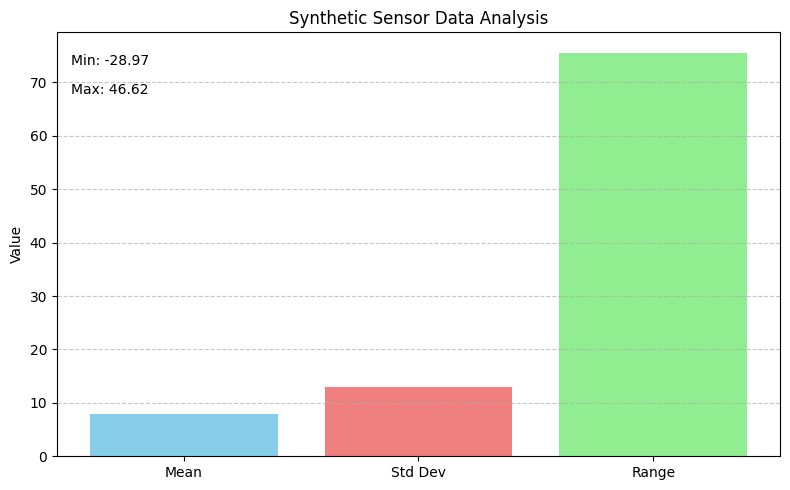

[Stage 3] Visualized summary statistics.

--- Workflow complete. ---


In [11]:
# 💻 Activity B.2 — Paste your AI-generated Separated Workflow Stages code here:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Often used for structured data, but numpy is sufficient here

# --- INTRODUCTION ---
# Scientific workflows often involve multiple steps: gathering data, cleaning it,
# analyzing it, and presenting results. Mixing all these steps into one large block
# of code (a 'monolith') can lead to many problems:
# - Hard to debug: If an error occurs, it's difficult to pinpoint the source.
# - Hard to reuse: You can't easily use your analysis code on a different dataset.
# - Hard to test: You can't easily verify each step works correctly in isolation.
# - Hard to collaborate: Team members might accidentally break parts of the code.
# - Inflexible: Changing one part (e.g., a new plot type) requires modifying the whole script.
#
# By organizing into independent stages (functions), we make the workflow:
# - Modular: Each function has a clear, single responsibility.
# - Reusable: Functions can be called with different inputs or in different scripts.
# - Testable: Each function can be tested independently.
# - Maintainable: Changes in one stage are less likely to break others.
# - Understandable: It's easier to follow the logic of the workflow.

# --- STAGE 1: Obtaining Data ---
# This function's sole responsibility is to get the raw sensor measurements.
# It should NOT perform any calculations or create any plots.
# Biologically: This simulates loading raw data from an fMRI scanner, EEG setup,
# or a lab sensor array.
def obtain_sensor_measurements(num_samples=1000, sensor_noise_std=5.0, signal_amplitude=10.0):
    """
    Generates synthetic sensor measurements over time.

    Args:
        num_samples (int): The number of data points to generate.
        sensor_noise_std (float): Standard deviation of random noise.
        signal_amplitude (float): Amplitude of a simulated underlying signal.

    Returns:
        numpy.ndarray: An array of raw sensor measurements.
    """
    # Simulate a baseline signal with some underlying rhythm (e.g., biological rhythm)
    time = np.linspace(0, 10, num_samples)
    underlying_signal = signal_amplitude * np.sin(time * 2) + signal_amplitude / 2

    # Add random noise, simulating real-world sensor imperfections or biological variability
    noise = np.random.normal(0, sensor_noise_std, num_samples)

    raw_data = underlying_signal + noise

    print(f"[Stage 1] Obtained {num_samples} raw sensor measurements.")
    return raw_data

# --- STAGE 2: Analyzing Data ---
# This function's sole responsibility is to process the raw data and calculate
# meaningful statistics. It should NOT load data or create plots.
# Biologically: This simulates applying signal processing, extracting features,
# or performing statistical tests on your experimental data.
def analyze_sensor_data(raw_measurements):
    """
    Calculates summary statistics from raw sensor measurements.

    Args:
        raw_measurements (numpy.ndarray): The raw data from Stage 1.

    Returns:
        dict: A dictionary containing calculated statistics (mean, std, range).
    """
    if not isinstance(raw_measurements, np.ndarray) or raw_measurements.ndim != 1:
        raise ValueError("Expected raw_measurements to be a 1D numpy array.")

    mean_val = np.mean(raw_measurements)
    std_val = np.std(raw_measurements)
    min_val = np.min(raw_measurements)
    max_val = np.max(raw_measurements)
    range_val = max_val - min_val

    summary_statistics = {
        'mean': mean_val,
        'std_dev': std_val,
        'min_value': min_val,
        'max_value': max_val,
        'range': range_val
    }

    print("[Stage 2] Analyzed data and calculated summary statistics.")
    return summary_statistics

# --- STAGE 3: Visualizing Results ---
# This function's sole responsibility is to take the processed results and
# present them graphically. It should NOT load data or perform calculations.
# Biologically: This simulates generating figures for a publication, presentation,
# or internal report to understand your findings.
def visualize_summary_statistics(stats_dict, plot_title="Sensor Measurement Summary"):
    """
    Creates a bar plot to visualize summary statistics.

    Args:
        stats_dict (dict): Dictionary of statistics from Stage 2.
        plot_title (str): Title for the generated plot.
    """
    labels = list(stats_dict.keys())
    values = list(stats_dict.values())

    # Exclude 'min_value', 'max_value' from the main bar plot to keep it clean,
    # but we can still print them or show them differently.
    plot_labels = ['Mean', 'Std Dev', 'Range']
    plot_values = [stats_dict['mean'], stats_dict['std_dev'], stats_dict['range']]

    plt.figure(figsize=(8, 5))
    plt.bar(plot_labels, plot_values, color=['skyblue', 'lightcoral', 'lightgreen'])
    plt.ylabel('Value')
    plt.title(plot_title)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add text for min/max values typically displayed on a plot or table
    plt.text(0.02, 0.95, f"Min: {stats_dict['min_value']:.2f}", transform=plt.gca().transAxes, ha='left', va='top')
    plt.text(0.02, 0.88, f"Max: {stats_dict['max_value']:.2f}", transform=plt.gca().transAxes, ha='left', va='top')

    plt.tight_layout()
    plt.show()
    print("[Stage 3] Visualized summary statistics.")


# --- Orchestrating the Workflow ---
# This is where we call our independent stages in sequence, passing information.

print("\n--- Running the structured scientific workflow ---")

# 1. Obtain Data
raw_sensor_data = obtain_sensor_measurements(num_samples=2000, sensor_noise_std=8.0, signal_amplitude=15.0)

# 2. Analyze Data (takes raw_sensor_data as input)
# If Stage 1 changes (e.g., loads from a file instead of generating), Stage 2 doesn't need to change,
# as long as the output 'raw_sensor_data' format remains consistent.
summary_stats = analyze_sensor_data(raw_sensor_data)

# 3. Visualize Results (takes summary_stats as input)
# If Stage 2 changes its calculation method, Stage 3 only needs to adapt if the structure
# of 'summary_stats' dictionary changes. It doesn't need to know *how* stats were calculated.
visualize_summary_statistics(summary_stats, plot_title="Synthetic Sensor Data Analysis")

print("\n--- Workflow complete. ---")

# --- What would go wrong if all three were mixed together? ---
# If all the code for data generation, analysis, and plotting were in one big block,
# making even a small change (e.g., trying a different statistical test, or changing
# the noise level of the simulated data) would mean you have to re-run and debug
# the entire monolithic script every time. It would be much harder to test if your
# statistics are correct independently of your data loading, or if your plot looks
# right independently of your analysis. It encourages 'spaghetti code' where logic
# is intertwined and difficult to follow or modify safely.

### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** Based on Activity B.1, how much faster was working memory (RAM) compared to saving and loading from disk? What happened as the data size grew?
* **Connecting to key concepts:** Activities B.1 and B.2 demonstrate **Concepts 26, 29, 36, 39, and 41** from your Reference Guide. Explain in plain language why a researcher should keep the data-loading stage of a workflow completely separate from the visualization stage.

---

## 📑 What Comes Next

The next four pre-workshop notebooks build directly on the foundations you have established here. Notebook 2 introduces working with datasets from many participants at once. Notebook 3 covers signal cleaning and filtering. Notebook 4 introduces pattern recognition and machine learning. Notebook 5 brings everything together into a complete integrated workflow.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all five pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities. Write the letter of the code cell (A.1, A.2, B.1, B.2) where your generated code best demonstrates each concept.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 1 — What a BMI does | [ 5 ] |
| Neuroscience | Concept 3 — Why signal delay matters | [ Enter Cell ID ] |
| Neuroscience | Concept 5 — How fMRI works | [ Enter Cell ID ] |
| Computing | Concept 26 — Working memory vs. storage | [ Enter Cell ID ] |
| Computing | Concept 36 — Organizing code into stages | [ Enter Cell ID ] |
| Computing | Concept 41 — Keeping stages independent | [ Enter Cell ID ] |
